In [269]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [270]:
data = pd.read_csv('train_FD004.txt')


In [271]:
import pandas as pd

index_names = ['unit_number', 'time_in_cycles']
setting_names = ['setting1', 'setting2', 'setting3']
sensor_names = ['sensor{}'.format(i) for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

data = pd.read_csv('train_FD004.txt', sep='\s+', header=None, names=col_names)

max_cycle = data.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycle.columns = ['unit_number', 'max_life']
data = data.merge(max_cycle, on='unit_number', how='left')
data['RUL'] = data['max_life'] - data['time_in_cycles']

data.drop('max_life', axis=1, inplace=True)

print(data.info()) 
print("-" * 30)
print(data[['unit_number', 'time_in_cycles', 'RUL']].head())

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
C:\Users\HP\AppData\Local\Temp\ipykernel_17916\1402635641.py:8: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv('train_FD004.txt', sep='\s+', header=None, names=col_names)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61249 entries, 0 to 61248
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_number     61249 non-null  int64  
 1   time_in_cycles  61249 non-null  int64  
 2   setting1        61249 non-null  float64
 3   setting2        61249 non-null  float64
 4   setting3        61249 non-null  float64
 5   sensor1         61249 non-null  float64
 6   sensor2         61249 non-null  float64
 7   sensor3         61249 non-null  float64
 8   sensor4         61249 non-null  float64
 9   sensor5         61249 non-null  float64
 10  sensor6         61249 non-null  float64
 11  sensor7         61249 non-null  float64
 12  sensor8         61249 non-null  float64
 13  sensor9         61249 non-null  float64
 14  sensor10        61249 non-null  float64
 15  sensor11        61249 non-null  float64
 16  sensor12        61249 non-null  float64
 17  sensor13        61249 non-null 

In [272]:
data.head()

,unit_number,time_in_cycles,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21,RUL
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,320
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,319
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,318
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,317
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,316


In [273]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61249 entries, 0 to 61248
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_number     61249 non-null  int64  
 1   time_in_cycles  61249 non-null  int64  
 2   setting1        61249 non-null  float64
 3   setting2        61249 non-null  float64
 4   setting3        61249 non-null  float64
 5   sensor1         61249 non-null  float64
 6   sensor2         61249 non-null  float64
 7   sensor3         61249 non-null  float64
 8   sensor4         61249 non-null  float64
 9   sensor5         61249 non-null  float64
 10  sensor6         61249 non-null  float64
 11  sensor7         61249 non-null  float64
 12  sensor8         61249 non-null  float64
 13  sensor9         61249 non-null  float64
 14  sensor10        61249 non-null  float64
 15  sensor11        61249 non-null  float64
 16  sensor12        61249 non-null  float64
 17  sensor13        61249 non-null 

In [274]:
data.duplicated().sum()

np.int64(0)

In [275]:
data["RUL"] = data["RUL"].clip(upper=125)

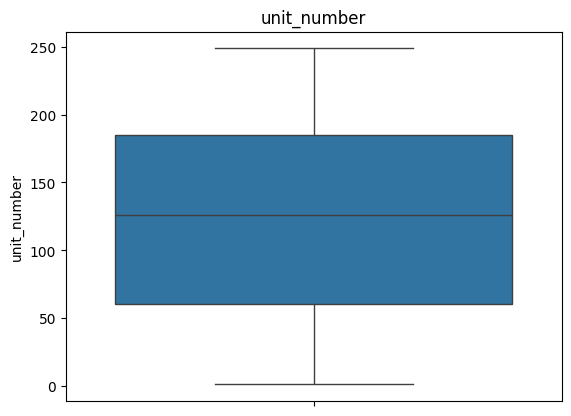

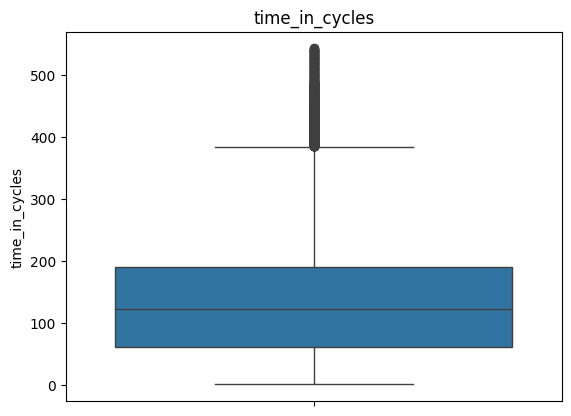

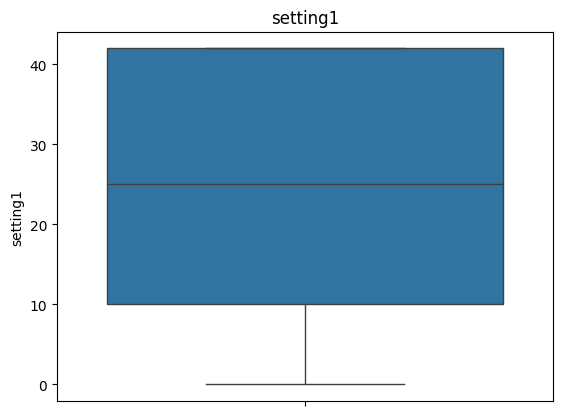

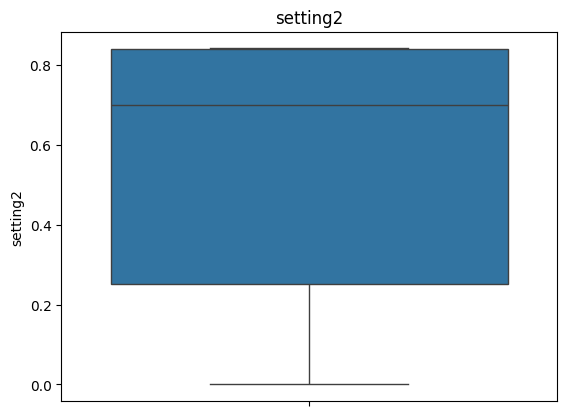

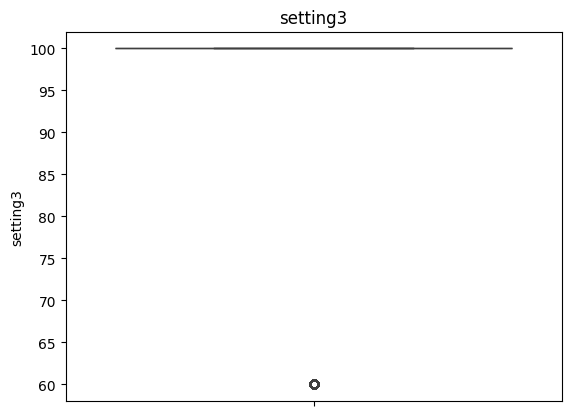

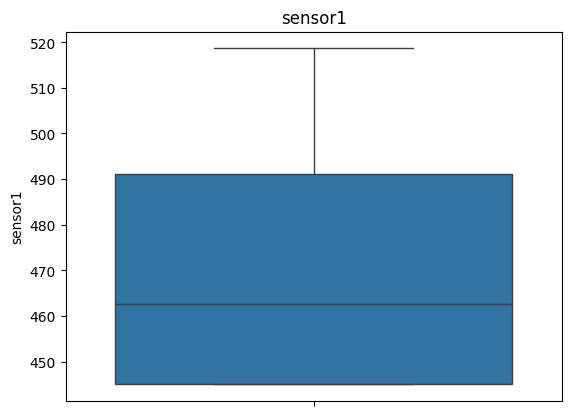

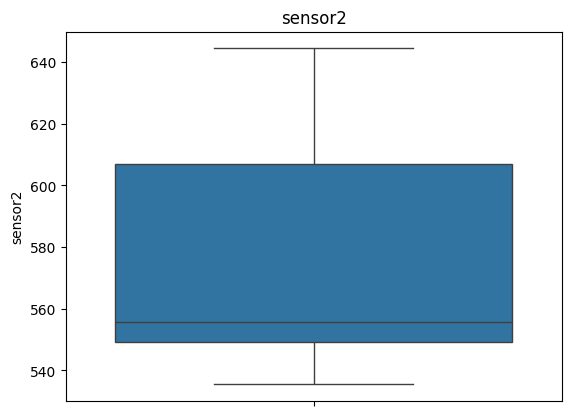

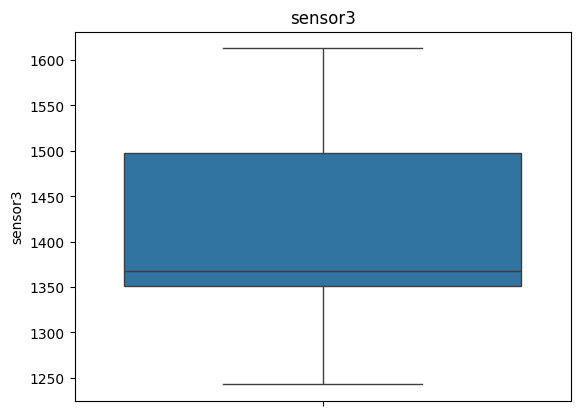

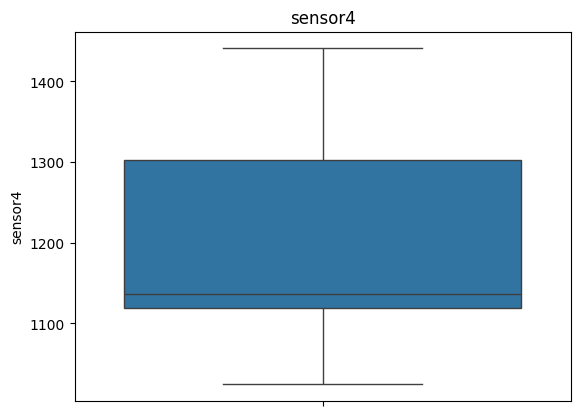

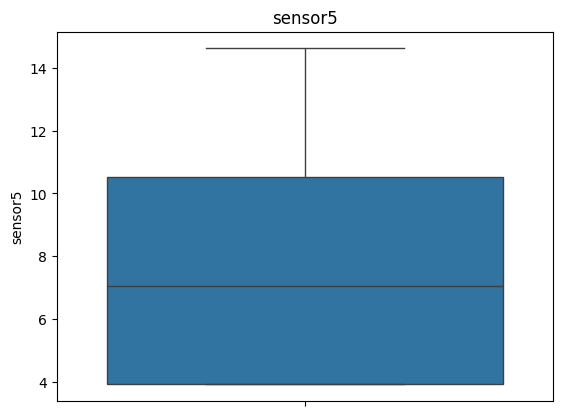

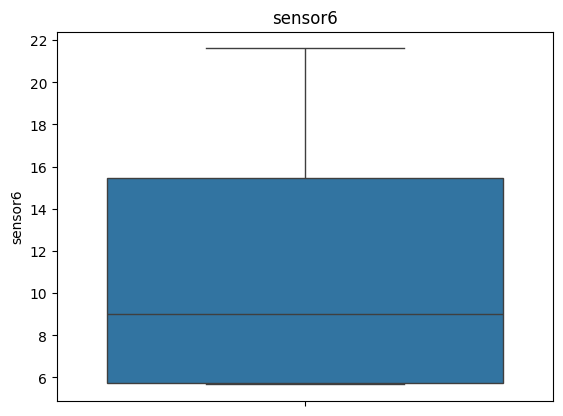

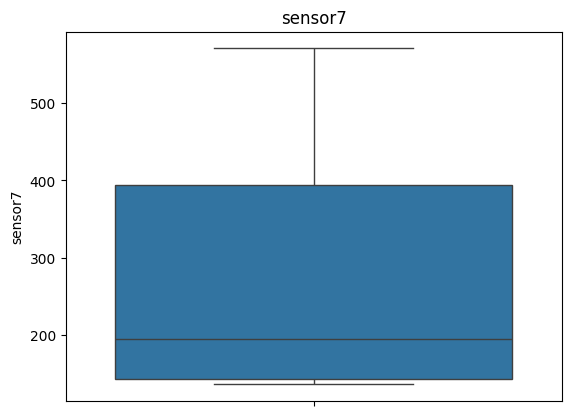

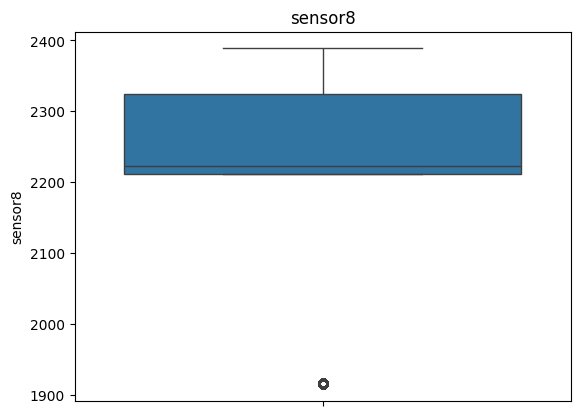

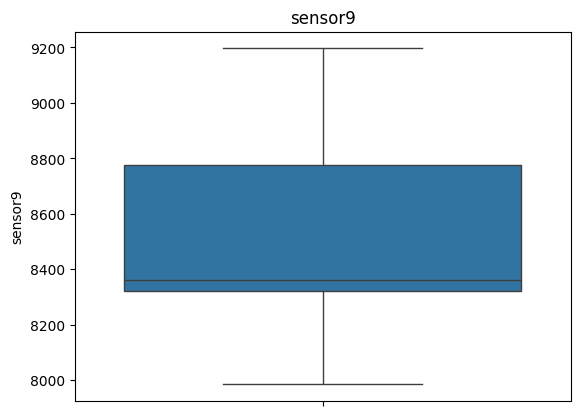

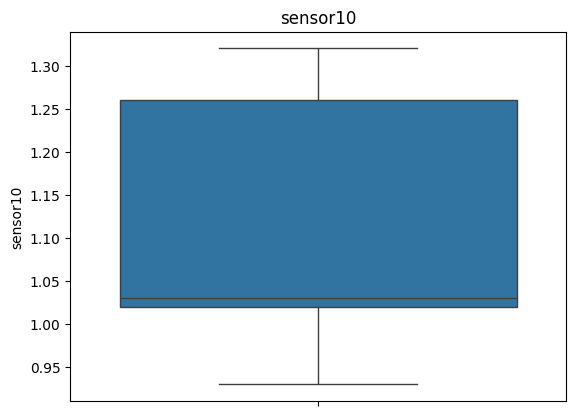

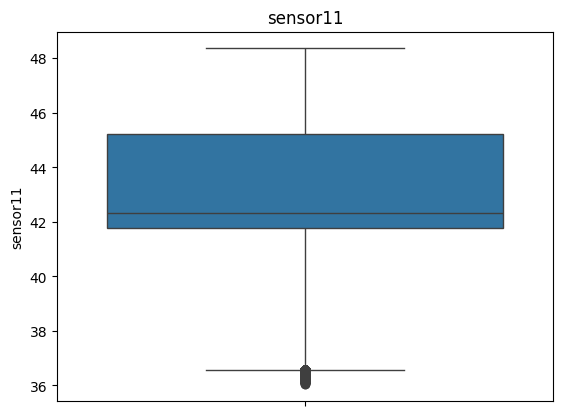

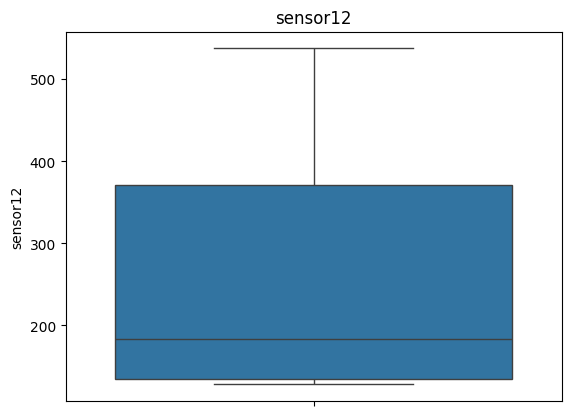

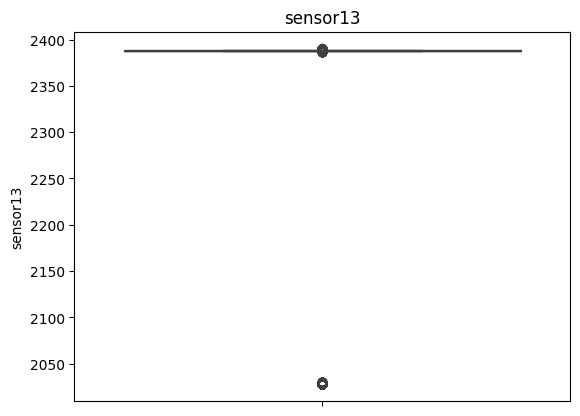

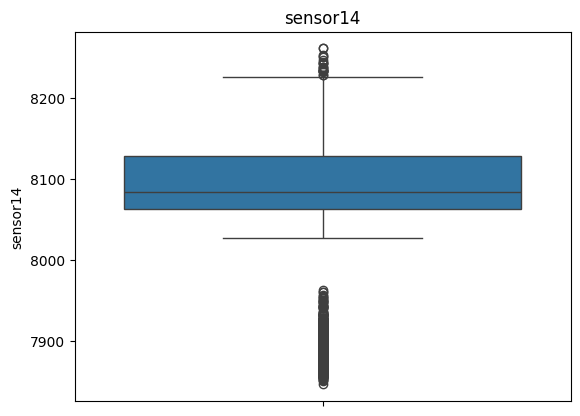

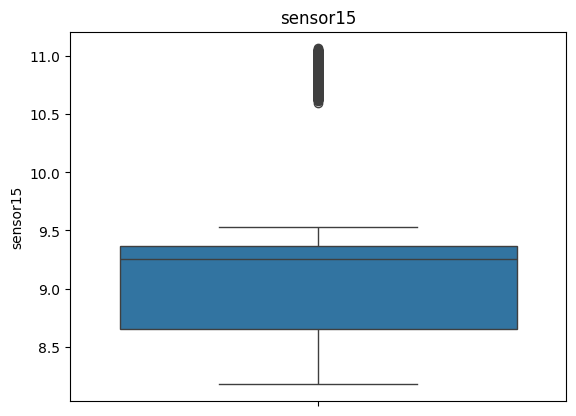

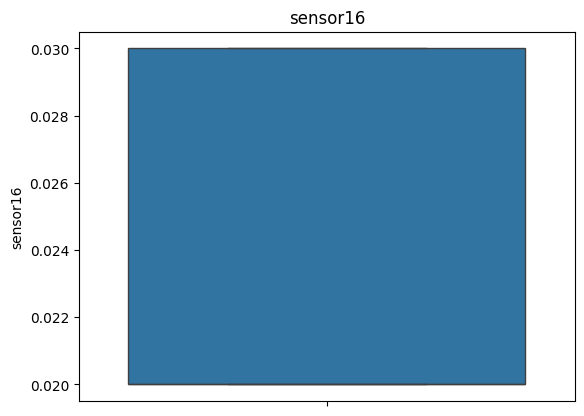

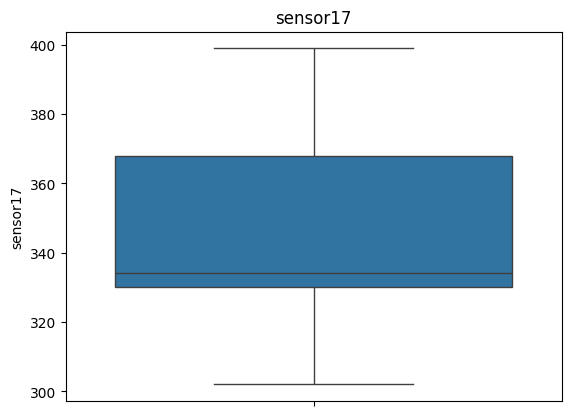

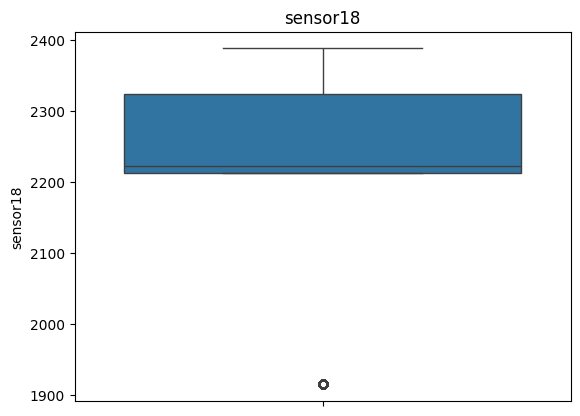

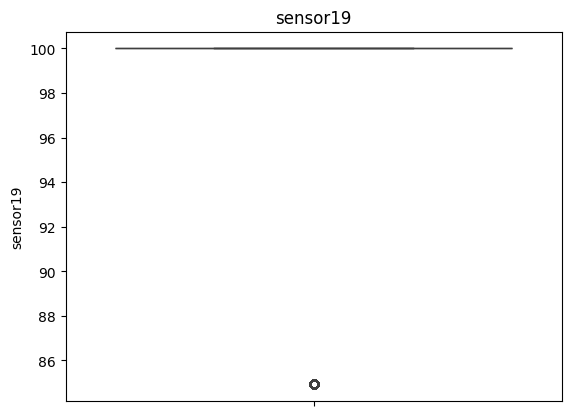

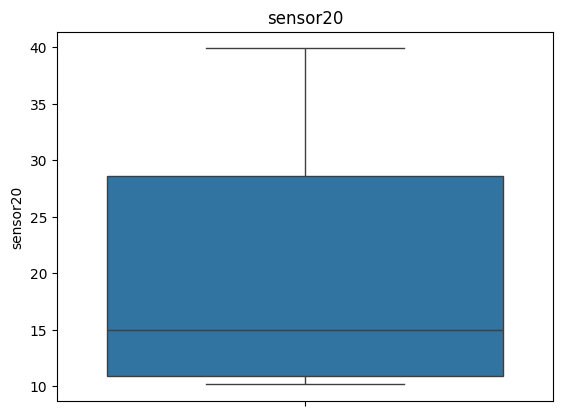

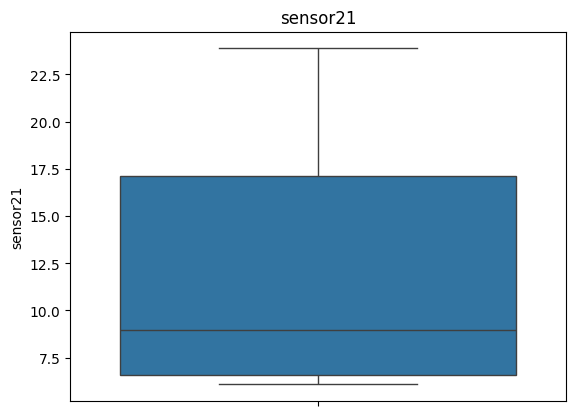

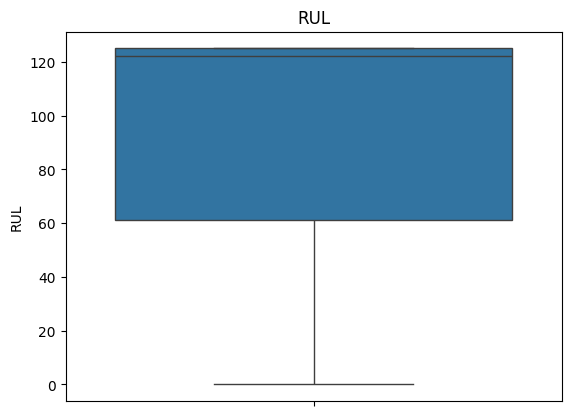

In [276]:
for i in data:
  sns.boxplot(data[i])
  plt.title(i)
  plt.show()

In [277]:
data.columns

Index(['unit_number', 'time_in_cycles', 'setting1', 'setting2', 'setting3',
       'sensor1', 'sensor2', 'sensor3', 'sensor4', 'sensor5', 'sensor6',
       'sensor7', 'sensor8', 'sensor9', 'sensor10', 'sensor11', 'sensor12',
       'sensor13', 'sensor14', 'sensor15', 'sensor16', 'sensor17', 'sensor18',
       'sensor19', 'sensor20', 'sensor21', 'RUL'],
      dtype='object')

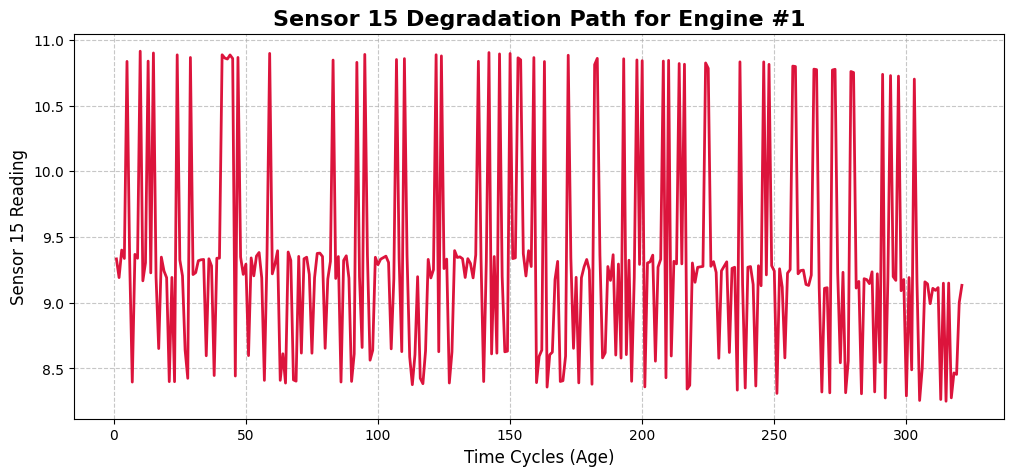

In [ ]:
engine_1_data = data[data['unit_number'] == 1]

plt.figure(figsize=(12, 5))
sns.lineplot(data=engine_1_data, x='time_in_cycles', y='sensor15', color='crimson', linewidth=2)

plt.title('Sensor 15 Degradation Path for Engine #1', fontsize=16, fontweight='bold')
plt.xlabel('Time Cycles (Age)', fontsize=12)
plt.ylabel('Sensor 15 Reading', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

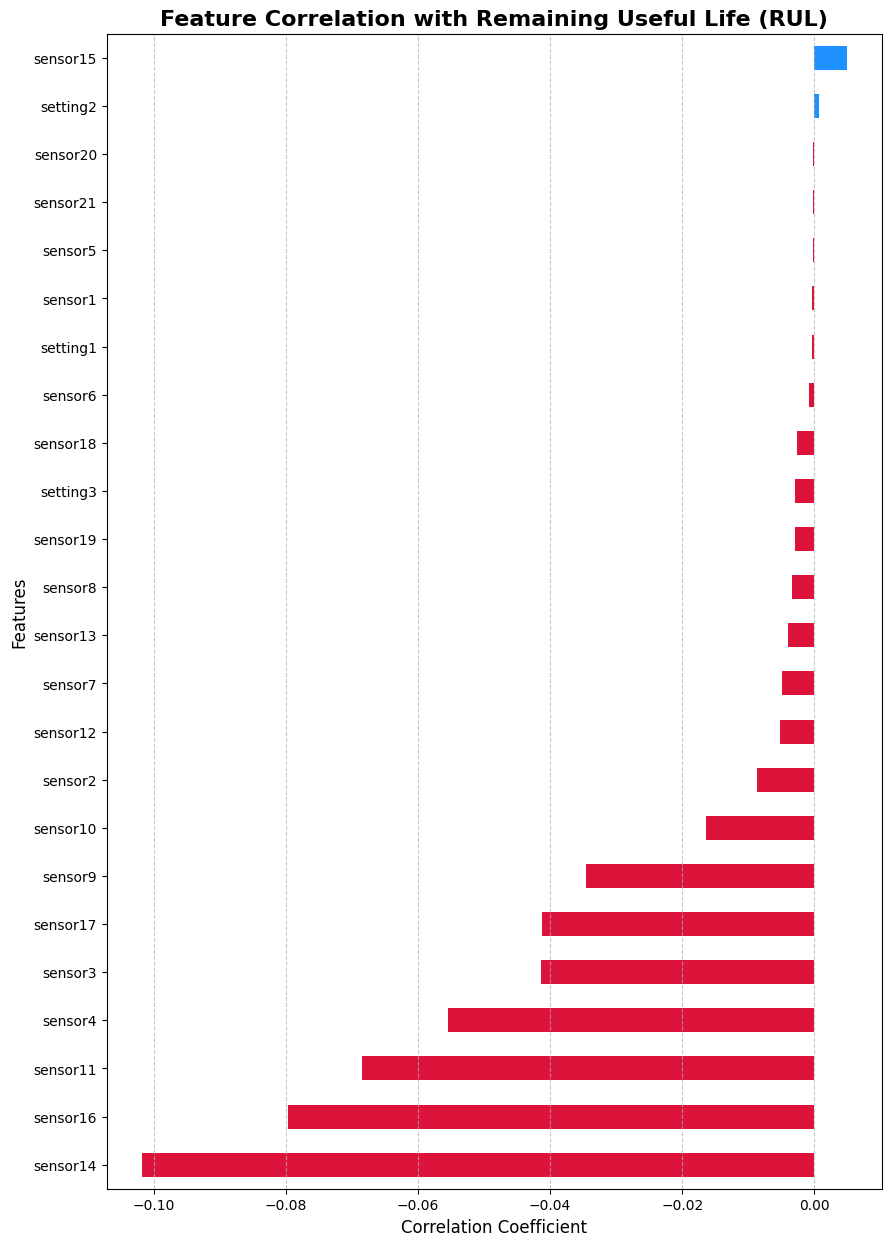

In [279]:
correlations = data.corr()['RUL'].drop(['RUL', 'unit_number', 'time_in_cycles'])
correlations = correlations.sort_values()

plt.figure(figsize=(10, 15)) 
colors = np.where(correlations < 0, 'crimson', 'dodgerblue')

correlations.plot(kind='barh', color=colors)
plt.title('Feature Correlation with Remaining Useful Life (RUL)', fontsize=16, fontweight='bold')
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [280]:
from pandas.core.window.rolling import Window
window=5
for col in data.columns:
    if col not in ["unit_number", "time_in_cycles", "RUL"]:
        data[col + "_mean"] = data.groupby("unit_number")[col].transform(lambda x: x.rolling(window).mean())
        data[col + "_std"] = data.groupby("unit_number")[col].transform(lambda x: x.rolling(window).std())

In [281]:
data = data.bfill()

In [282]:
features=sensor_names+setting_names
final_features = features + [col + '_mean' for col in features] + [col + '_std' for col in features]

In [283]:
from sklearn.preprocessing import RobustScaler
final_features = [f for f in final_features if f in data.columns]
scaler = RobustScaler() 
data[final_features] = scaler.fit_transform(data[final_features])
X = data[final_features]
y = data['RUL']

In [284]:
print(X.columns.tolist())

['sensor1', 'sensor2', 'sensor3', 'sensor4', 'sensor5', 'sensor6', 'sensor7', 'sensor8', 'sensor9', 'sensor10', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor16', 'sensor17', 'sensor18', 'sensor19', 'sensor20', 'sensor21', 'setting1', 'setting2', 'setting3', 'sensor1_mean', 'sensor2_mean', 'sensor3_mean', 'sensor4_mean', 'sensor5_mean', 'sensor6_mean', 'sensor7_mean', 'sensor8_mean', 'sensor9_mean', 'sensor10_mean', 'sensor11_mean', 'sensor12_mean', 'sensor13_mean', 'sensor14_mean', 'sensor15_mean', 'sensor16_mean', 'sensor17_mean', 'sensor18_mean', 'sensor19_mean', 'sensor20_mean', 'sensor21_mean', 'setting1_mean', 'setting2_mean', 'setting3_mean', 'sensor1_std', 'sensor2_std', 'sensor3_std', 'sensor4_std', 'sensor5_std', 'sensor6_std', 'sensor7_std', 'sensor8_std', 'sensor9_std', 'sensor10_std', 'sensor11_std', 'sensor12_std', 'sensor13_std', 'sensor14_std', 'sensor15_std', 'sensor16_std', 'sensor17_std', 'sensor18_std', 'sensor19_std', 'sensor20_std', 'sensor21_

In [285]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
groups = data['unit_number']

for train_idx, test_idx in gss.split(X, y, groups):
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)

settings_cols = ['setting1', 'setting2', 'setting3']

X_train['cluster'] = kmeans.fit_predict(X_train[settings_cols])
X_test['cluster'] = kmeans.predict(X_test[settings_cols])

X_train = pd.get_dummies(X_train, columns=['cluster'], prefix='Condition')
X_test = pd.get_dummies(X_test, columns=['cluster'], prefix='Condition')

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

xgb_boss = XGBRegressor(
    n_estimators=500,      
    learning_rate=0.02,    
    max_depth=7,          
    subsample=0.9,         
    colsample_bytree=0.9,
    random_state=42
)

xgb_boss.fit(X_train, y_train)

y_train_pred = xgb_boss.predict(X_train)
y_test_pred = xgb_boss.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("-" * 35)
print(f" Train RMSE: {rmse_train:.2f}")
print(f" Test RMSE:  {rmse_test:.2f}")
print("-" * 35)
print(f" Train R2: {r2_train*100:.2f}%")
print(f" Test R2:  {r2_test*100:.2f}%")
print("-" * 35)

-----------------------------------
 Train RMSE: 14.25
 Test RMSE:  19.74
-----------------------------------
 Train R2: 87.68%
 Test R2:  76.69%
-----------------------------------


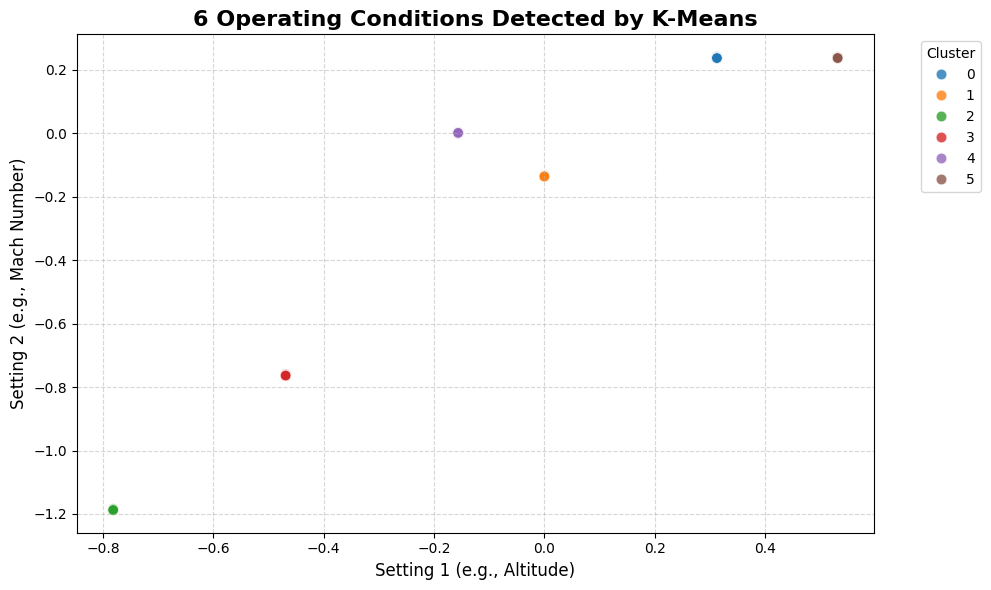

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

temp_data = X_train.copy()

settings_cols = ['setting1', 'setting2', 'setting3']
temp_data['plot_cluster'] = kmeans.predict(temp_data[settings_cols])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=temp_data, x='setting1', y='setting2', hue='plot_cluster', palette='tab10', s=60, alpha=0.8)

plt.title('6 Operating Conditions Detected by K-Means', fontsize=16, fontweight='bold')
plt.xlabel('Setting 1 (e.g., Altitude)', fontsize=12)
plt.ylabel('Setting 2 (e.g., Mach Number)', fontsize=12)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [287]:
data.describe()

,unit_number,time_in_cycles,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor17_mean,sensor17_std,sensor18_mean,sensor18_std,sensor19_mean,sensor19_std,sensor20_mean,sensor20_std,sensor21_mean,sensor21_std
count,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,...,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,6.124900e+04,61249.000000,61249.000000,61249.000000,61249.000000
mean,124.325181,134.311417,-0.031306,-0.218315,-5.968424,0.223911,0.410115,0.341912,0.354914,0.148506,...,0.031813,-0.016310,-0.058780,-0.192841,0.252722,-4.103105e-01,0.035934,-0.155696,0.036292,-0.154588
std,71.995350,89.783389,0.461991,0.527242,14.251954,0.572350,0.646738,0.722868,0.651600,0.548090,...,0.723684,0.661264,0.739134,0.545356,0.801635,5.348924e-01,0.751863,0.683703,0.752587,0.682914
min,1.000000,1.000000,-0.781452,-1.187850,-40.000000,-0.379736,-0.350883,-0.851161,-0.614318,-0.475038,...,-2.441860,-2.244420,-3.614512,-1.333078,-4.000000,-1.000000e+00,-1.736914,-2.238507,-1.740081,-2.230997
25%,60.000000,62.000000,-0.468745,-0.762430,0.000000,-0.379736,-0.111015,-0.116634,-0.095178,-0.475038,...,-0.465116,-0.481967,-0.496599,-0.706353,0.000000,-1.000000e+00,-0.491842,-0.611144,-0.491802,-0.609896
50%,126.000000,123.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
75%,185.000000,191.000000,0.531255,0.237570,0.000000,0.620264,0.888985,0.883366,0.904822,0.524962,...,0.534884,0.518033,0.503401,0.293647,1.000000,2.635736e-16,0.508158,0.388856,0.508198,0.390104
max,249.000000,543.000000,0.531564,0.240964,0.000000,1.215198,1.535850,1.670321,1.659204,1.145234,...,2.732558,1.823141,1.748299,0.916778,1.000000,2.247449e-01,3.062882,1.254907,3.080619,1.239559


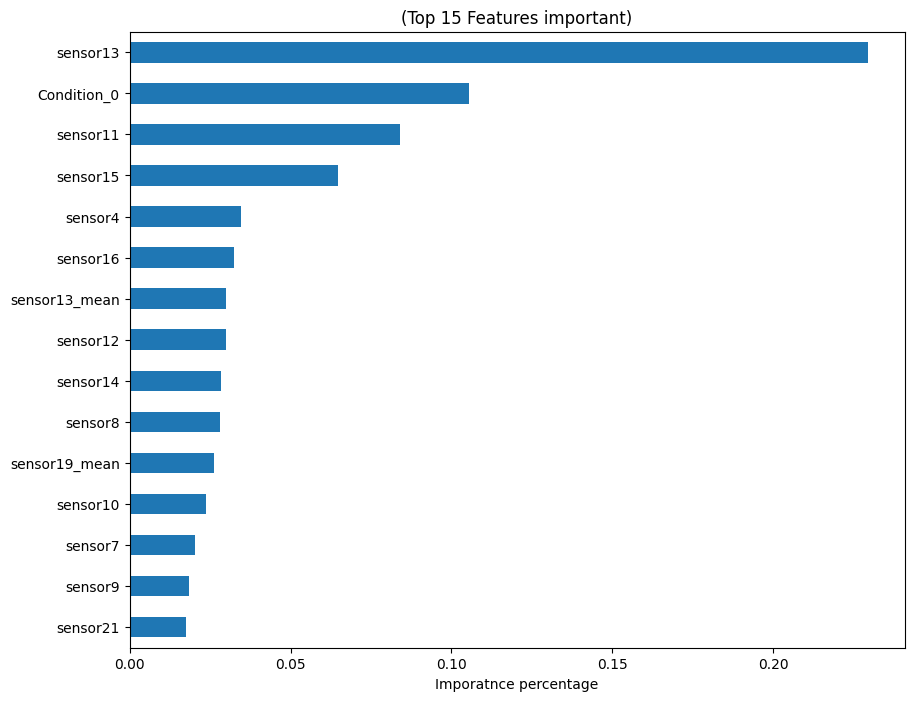

In [288]:
import matplotlib.pyplot as plt
import pandas as pd

feat_importances = pd.Series(xgb_boss.feature_importances_, index=X_test.columns)

plt.figure(figsize=(10, 8))


feat_importances.nlargest(15).sort_values().plot(kind='barh')

plt.title('(Top 15 Features important)')
plt.xlabel('Imporatnce percentage')
plt.show()

In [289]:
test_data4 = pd.read_csv(r'test_FD004.txt', sep=r'\s+', header=None)
test_data4.dropna(axis=1, how='all', inplace=True)
test_data4.columns = col_names

current_features = [col for col in features ]

window = 5
for col in current_features:
    test_data4[col + '_mean'] = test_data4.groupby('unit_number')[col].transform(lambda x: x.rolling(window).mean())
    test_data4[col + '_std'] = test_data4.groupby('unit_number')[col].transform(lambda x: x.rolling(window).std())

test_data4 = test_data4.bfill()

test_last = test_data4.groupby('unit_number').last().reset_index()

test_last[final_features] = scaler.transform(test_last[final_features])

settings_cols = ['setting1', 'setting2', 'setting3']
test_last['cluster'] = kmeans.predict(test_last[settings_cols])

test_last = pd.get_dummies(test_last, columns=['cluster'], prefix='Condition')

X_final_test = test_last.reindex(columns=X_train.columns, fill_value=0)

# ==================================================
true_rul2 = pd.read_csv(r'RUL_FD004.txt', sep=r'\s+', header=None).iloc[:, 0]
true_rul2_clipped = true_rul2.clip(upper=125)

final_predictions = xgb_boss.predict(X_final_test)

final_rmse = np.sqrt(mean_squared_error(true_rul2_clipped, final_predictions))
final_r2 = r2_score(true_rul2_clipped, final_predictions)

print("=" * 40)
print(f" FINAL EXAM RMSE: {final_rmse:.2f}")
print(f" FINAL EXAM R2 SCORE: {final_r2 * 100:.2f}%")
print("=" * 40)

 FINAL EXAM RMSE: 19.20
 FINAL EXAM R2 SCORE: 80.05%


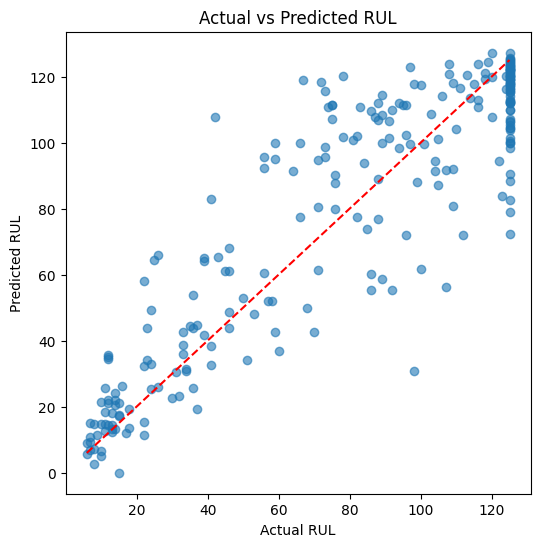

In [290]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(true_rul2_clipped, final_predictions, alpha=0.6)

plt.plot([true_rul2_clipped.min(), true_rul2_clipped.max()],
         [true_rul2_clipped.min(), true_rul2_clipped.max()],
         'r--')

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.show()

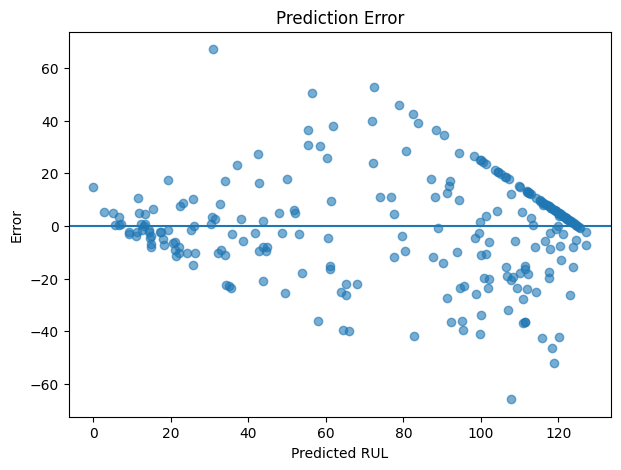

In [291]:
error = true_rul2_clipped - final_predictions


plt.figure(figsize=(7,5))
plt.scatter(final_predictions, error, alpha=0.6)

plt.axhline(0)

plt.xlabel("Predicted RUL")
plt.ylabel("Error")
plt.title("Prediction Error")

plt.show()

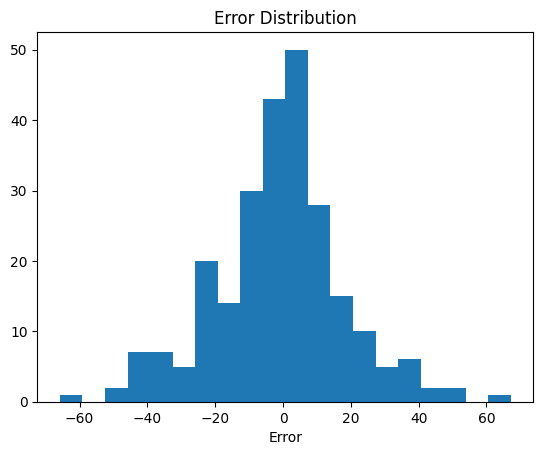

In [292]:
plt.hist(error, bins=20)

plt.xlabel("Error")
plt.title("Error Distribution")

plt.show()


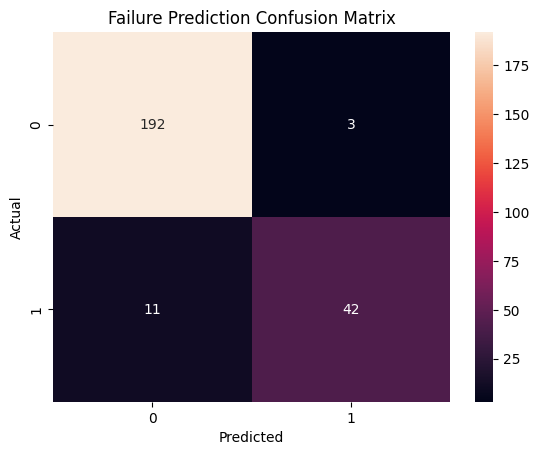

In [293]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = np.where(true_rul2_clipped <= 30, 1, 0)
y_pred = np.where(final_predictions <= 30, 1, 0)

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Failure Prediction Confusion Matrix")

plt.show()

In [294]:
import joblib
joblib.dump(xgb_boss, 'xgb_model_fd004.pkl')

joblib.dump(scaler, 'scaler_fd004.pkl')

joblib.dump(kmeans, 'kmeans_fd004.pkl')
joblib.dump(xgb_boss, 'model4.pkl', compress=3)

joblib.dump(X_train.columns.tolist(), 'features_fd004.pkl')

print("saved succefully!")

saved succefully!
